---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 10 / 32 — Bloque I

**Nivel GCE:** 1 (Localización)

**Dataset:** `syn_mediation`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 10: Mediación Causal — Descomposición de Efectos y Mecanismos

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 10 / 32 — Bloque I

---

## 1. Marco Teórico

### 1.1 El marco contrafactual anidado

Hasta ahora hemos estimado **efectos totales** $Y(1) - Y(0)$. Pero muchas preguntas causales requieren descomponer: ¿por qué opera el tratamiento? ¿A través de qué mecanismo?

La **mediación** introduce un mediador $M$ entre tratamiento $X$ y outcome $Y$:

$$X \to M \to Y$$
$$X \to Y \text{ (efecto directo)}$$

### 1.2 Definición formal de efectos causalmente estructurales

Definimos cuatro cantidades (Pearl 2001; VanderWeele 2015):

- **Total Effect (TE):** $\mathbb{E}[Y(1, M(1))] - \mathbb{E}[Y(0, M(0))]$
- **Controlled Direct Effect (CDE):** $\mathbb{E}[Y(1, m)] - \mathbb{E}[Y(0, m)]$ para $m$ fijo
- **Natural Direct Effect (NDE):** $\mathbb{E}[Y(1, M(0))] - \mathbb{E}[Y(0, M(0))]$
- **Natural Indirect Effect (NIE):** $\mathbb{E}[Y(1, M(1))] - \mathbb{E}[Y(1, M(0))]$

Por construcción: **TE = NDE + NIE**.

### 1.3 Condiciones de identificación (ignorabilidad secuencial)

Para identificar NDE y NIE necesitamos:

1. $(Y(1, m), Y(0, m), M(1), M(0)) \perp X | C$ — sin confusión X-Y
2. $Y(d, m) \perp M | X=d, C$ — sin confusión M-Y condicional en X

### 1.4 La fórmula de mediación no paramétrica (Pearl)

$$\text{NDE} = \sum_{m} \left[\mathbb{E}[Y|X=1, M=m, C] - \mathbb{E}[Y|X=0, M=m, C]\right] P(M=m | X=0, C) P(C)$$

### 1.5 El colapso paramétrico: de Pearl a Baron-Kenny

Bajo linealidad (sin interacciones), la fórmula se simplifica al **método de Baron-Kenny (1986)**:

- Regresión 1: $Y = \alpha + cX + \epsilon$ (efecto total $c$)
- Regresión 2: $M = \alpha_m + aX + \epsilon_m$ (efecto de X sobre M)
- Regresión 3: $Y = \alpha_y + c'X + bM + \epsilon_y$ (efecto directo $c'$, $b$)

Entonces: $\text{NDE} = c'$, $\text{NIE} = a \cdot b$, $\text{TE} = c' + a \cdot b = c$.

### 1.6 Dataset: `syn_mediation` (sintético)

Diseñado para validación directa:
- `treatment`: $X \in \{0, 1\}$
- `x_baseline`: covariable
- `mediator`: $M$ (variable mediadora)
- `y_outcome`: $Y$
- `truth_instructor_only.csv`:
  - `direct_effect_truth = 1.0`
  - `indirect_effect_truth = 0.8`
  - `total_effect_truth = 1.8`


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

DATA_DIR = '../datos'
df = pd.read_csv(f'{DATA_DIR}/synthetic/mediation/mediation_post_treatment/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/mediation/mediation_post_treatment/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas: {list(df.columns)}')
print(f'\nGround truth (constante):')
print(f'  Direct effect (δ):  {truth.direct_effect_truth.iloc[0]:.4f}')
print(f'  Indirect effect (βγ): {truth.indirect_effect_truth.iloc[0]:.4f}')
print(f'  Total effect (δ+βγ): {truth.total_effect_truth.iloc[0]:.4f}')

print(f'\nEstadísticas:')
print(df.describe().round(3))


Dataset: 3500 observaciones
Columnas: ['id', 'treatment', 'x_baseline', 'mediator', 'y_outcome']

Ground truth (constante):
  Direct effect (δ):  1.0000
  Indirect effect (βγ): 0.8000
  Total effect (δ+βγ): 1.8000

Estadísticas:
             id  treatment  x_baseline  mediator  y_outcome
count  3500.000   3500.000    3500.000  3500.000   3500.000
mean   1750.500      0.499      -0.015     0.478      1.890
std    1010.507      0.500       1.003     1.190      1.758
min       1.000      0.000      -3.332    -3.276     -4.364
25%     875.750      0.000      -0.685    -0.310      0.659
50%    1750.500      0.000      -0.011     0.511      1.908
75%    2625.250      1.000       0.658     1.292      3.111
max    3500.000      1.000       3.683     4.486      7.100


> 💡 **Interpretación del resultado.** `syn_mediation` aporta 3 500 unidades con tratamiento, mediador y outcome, y un ground truth con efecto directo $\delta=1.0000$, indirecto $\beta\gamma=0.8000$ y total 1.8000. Conocer estos valores permite medir el error de Baron-Kenny y de la G-computation en las secciones 3–4 (§1.6).


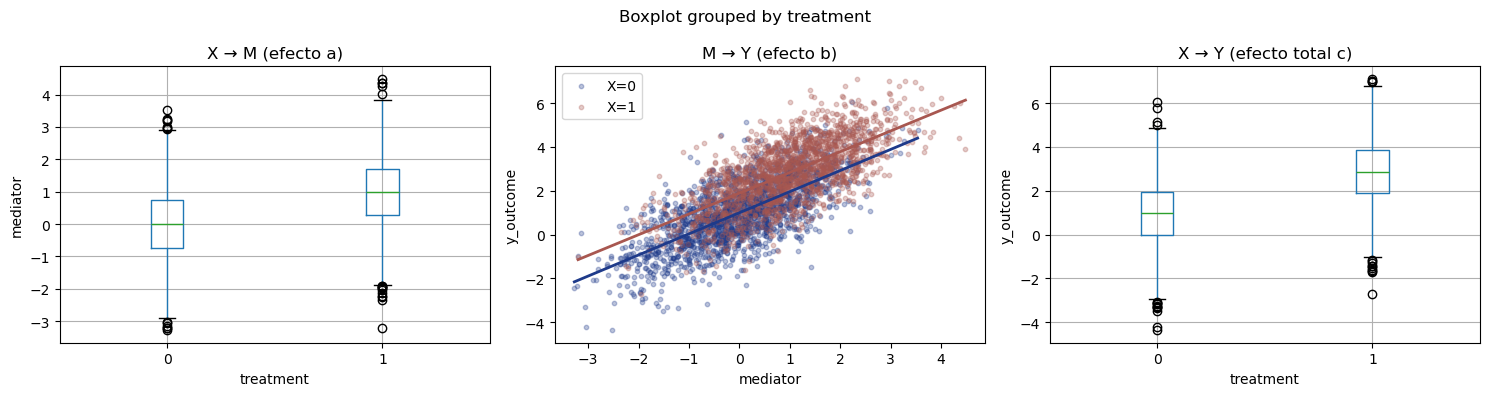

In [2]:
# === 2. Visualización: relaciones X → M → Y ===
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# X vs M
df.boxplot(column='mediator', by='treatment', ax=axes[0])
axes[0].set_title('X → M (efecto a)')
axes[0].set_xlabel('treatment'); axes[0].set_ylabel('mediator')
plt.suptitle('')

# M vs Y (coloreado por X)
for x, color, label in [(0, '#1E3A8A', 'X=0'), (1, '#A85750', 'X=1')]:
    sub = df[df.treatment == x]
    axes[1].scatter(sub['mediator'], sub['y_outcome'], alpha=0.3, s=10, c=color, label=label)
    # Línea de regresión
    z = np.polyfit(sub['mediator'], sub['y_outcome'], 1)
    x_grid = np.linspace(sub['mediator'].min(), sub['mediator'].max(), 50)
    axes[1].plot(x_grid, np.polyval(z, x_grid), color=color, linewidth=2)
axes[1].set_xlabel('mediator'); axes[1].set_ylabel('y_outcome')
axes[1].set_title('M → Y (efecto b)')
axes[1].legend()

# X vs Y (efecto total c)
df.boxplot(column='y_outcome', by='treatment', ax=axes[2])
axes[2].set_title('X → Y (efecto total c)')
axes[2].set_xlabel('treatment'); axes[2].set_ylabel('y_outcome')

plt.tight_layout()
plt.show()


> 💡 **Interpretación de la figura.** Los paneles muestran los eslabones de la cadena causal: $X\to M$ (efecto $a$), $M\to Y$ (efecto $b$) y $X\to Y$ (efecto total $c$), con pendientes positivas en los tres. La asociación $M$–$Y$ es el eslabón que Baron-Kenny explota para aislar el efecto indirecto $a\cdot b$ (§1.5).


In [3]:
# === 3. Método Baron-Kenny (lineal, sin interacciones) ===
# Regresión 1: Y ~ X (efecto total c)
m_total = smf.ols('y_outcome ~ treatment + x_baseline', data=df).fit()
c = m_total.params['treatment']

# Regresión 2: M ~ X (efecto a)
m_med = smf.ols('mediator ~ treatment + x_baseline', data=df).fit()
a = m_med.params['treatment']

# Regresión 3: Y ~ X + M (efecto directo c', efecto b)
m_dir = smf.ols('y_outcome ~ treatment + mediator + x_baseline', data=df).fit()
c_prime = m_dir.params['treatment']
b = m_dir.params['mediator']

# Calcular efectos
nde = c_prime
nie = a * b
te = nde + nie

label_total = 'Efecto total c (Y ~ X)'
label_directo = "Efecto directo c' (Y ~ X + M)"
label_indirecto = 'Efecto indirecto a*b'
label_suma = "Suma c' + a*b"

print(f'=== Método Baron-Kenny ===')
print(f'{"Cantidad":<30} {"Estimado":>10} {"Verdadero":>12} {"Error":>10}')
print(f'{"-"*65}')
print(f'{label_total:<30} {c:>10.4f} {truth.total_effect_truth.iloc[0]:>12.4f} {c - truth.total_effect_truth.iloc[0]:>10.4f}')
print(f'{label_directo:<30} {c_prime:>10.4f} {truth.direct_effect_truth.iloc[0]:>12.4f} {c_prime - truth.direct_effect_truth.iloc[0]:>10.4f}')
print(f'{label_indirecto:<30} {nie:>10.4f} {truth.indirect_effect_truth.iloc[0]:>12.4f} {nie - truth.indirect_effect_truth.iloc[0]:>10.4f}')
print(f'{label_suma:<30} {nde+nie:>10.4f} {truth.total_effect_truth.iloc[0]:>12.4f} {(nde+nie) - truth.total_effect_truth.iloc[0]:>10.4f}')
print(f'\nProporción mediada: {100*nie/te:.1f}%')

=== Método Baron-Kenny ===
Cantidad                         Estimado    Verdadero      Error
-----------------------------------------------------------------
Efecto total c (Y ~ X)             1.8388       1.8000     0.0388
Efecto directo c' (Y ~ X + M)      1.0503       1.0000     0.0503
Efecto indirecto a*b               0.7885       0.8000    -0.0115
Suma c' + a*b                      1.8388       1.8000     0.0388

Proporción mediada: 42.9%


> 💡 **Interpretación del resultado.** Baron-Kenny recupera el efecto total (1.8388 vs 1.8000), el directo (1.0503 vs 1.0000) y el indirecto (0.7885 vs 0.8000) con errores pequeños, y una proporción mediada de 42.9%. La descomposición $c = c' + a\cdot b$ (1.8388 = 1.0503 + 0.7885) es exacta en el modelo lineal sin interacciones: el colapso paramétrico de Pearl a Baron-Kenny (§1.5).


In [4]:
# === 4. G-Computation (más general, permite interacciones) ===
# Para NDE: E[Y(1, M(0))] - E[Y(0, M(0))]
# Para NIE: E[Y(1, M(1))] - E[Y(1, M(0))]

# Paso 1: ajustar modelo de M dado X
m_m = smf.ols('mediator ~ treatment + x_baseline', data=df).fit()

# Paso 2: ajustar modelo de Y dado X, M (con interacciones si queréis)
m_y = smf.ols('y_outcome ~ treatment * mediator + x_baseline', data=df).fit()

# Paso 3: predecir M(0) y M(1) para cada observación
df['M0_hat'] = m_m.predict(df.assign(treatment=0))
df['M1_hat'] = m_m.predict(df.assign(treatment=1))

# Paso 4: predecir Y(1, M(0)), Y(0, M(0)), Y(1, M(1)) para cada observación
df['Y_1_M0'] = m_y.predict(df.assign(treatment=1, mediator=df['M0_hat']))
df['Y_0_M0'] = m_y.predict(df.assign(treatment=0, mediator=df['M0_hat']))
df['Y_1_M1'] = m_y.predict(df.assign(treatment=1, mediator=df['M1_hat']))

# Paso 5: promediar
nde_g = (df['Y_1_M0'] - df['Y_0_M0']).mean()
nie_g = (df['Y_1_M1'] - df['Y_1_M0']).mean()
te_g = nde_g + nie_g

print(f'=== G-Computation (permite interacciones) ===')
print(f'{"Cantidad":<25} {"Estimado":>10} {"Verdadero":>12} {"Error":>10}')
print(f'{"-"*60}')
print(f'{"NDE (Y(1,M0)-Y(0,M0))":<25} {nde_g:>10.4f} {truth.direct_effect_truth.iloc[0]:>12.4f} {nde_g - truth.direct_effect_truth.iloc[0]:>10.4f}')
print(f'{"NIE (Y(1,M1)-Y(1,M0))":<25} {nie_g:>10.4f} {truth.indirect_effect_truth.iloc[0]:>12.4f} {nie_g - truth.indirect_effect_truth.iloc[0]:>10.4f}')
print(f'{"TE (NDE + NIE)":<25} {te_g:>10.4f} {truth.total_effect_truth.iloc[0]:>12.4f} {te_g - truth.total_effect_truth.iloc[0]:>10.4f}')
print(f'\nProporción mediada: {100*nie_g/te_g:.1f}%')


=== G-Computation (permite interacciones) ===
Cantidad                    Estimado    Verdadero      Error
------------------------------------------------------------
NDE (Y(1,M0)-Y(0,M0))         1.0631       1.0000     0.0631
NIE (Y(1,M1)-Y(1,M0))         0.7756       0.8000    -0.0244
TE (NDE + NIE)                1.8388       1.8000     0.0388

Proporción mediada: 42.2%


> 💡 **Interpretación del resultado.** La G-computation estima NDE = 1.0631, NIE = 0.7756 y TE = 1.8388, con proporción mediada 42.2%: resultados casi idénticos a Baron-Kenny en este DGP lineal. Su ventaja (Sección 4) es permitir interacciones y no linealidad, como mostrará la fragilidad de Baron-Kenny en la sección 5.bis.


In [5]:
# === 5. Bootstrap IC 95% para NDE y NIE ===
np.random.seed(42)
n_boot = 500
nde_boot = np.zeros(n_boot)
nie_boot = np.zeros(n_boot)
n = len(df)

for i in range(n_boot):
    idx = np.random.choice(n, size=n, replace=True)
    df_b = df.iloc[idx].copy()
    try:
        m_m_b = smf.ols('mediator ~ treatment + x_baseline', data=df_b).fit()
        m_y_b = smf.ols('y_outcome ~ treatment * mediator + x_baseline', data=df_b).fit()
        df_b['M0'] = m_m_b.predict(df_b.assign(treatment=0))
        df_b['M1'] = m_m_b.predict(df_b.assign(treatment=1))
        df_b['Y_1_M0'] = m_y_b.predict(df_b.assign(treatment=1, mediator=df_b['M0']))
        df_b['Y_0_M0'] = m_y_b.predict(df_b.assign(treatment=0, mediator=df_b['M0']))
        df_b['Y_1_M1'] = m_y_b.predict(df_b.assign(treatment=1, mediator=df_b['M1']))
        nde_boot[i] = (df_b['Y_1_M0'] - df_b['Y_0_M0']).mean()
        nie_boot[i] = (df_b['Y_1_M1'] - df_b['Y_1_M0']).mean()
    except:
        nde_boot[i] = np.nan
        nie_boot[i] = np.nan

nde_boot = nde_boot[~np.isnan(nde_boot)]
nie_boot = nie_boot[~np.isnan(nie_boot)]

print(f'=== Bootstrap IC 95% ===')
print(f'NDE: estimado {nde_g:.4f}, IC 95% [{np.percentile(nde_boot, 2.5):.4f}, {np.percentile(nde_boot, 97.5):.4f}]')
print(f'NIE: estimado {nie_g:.4f}, IC 95% [{np.percentile(nie_boot, 2.5):.4f}, {np.percentile(nie_boot, 97.5):.4f}]')
print(f'\nValidación ground truth:')
print(f'  NDE true = {truth.direct_effect_truth.iloc[0]:.4f}, ¿en IC? {np.percentile(nde_boot, 2.5) <= truth.direct_effect_truth.iloc[0] <= np.percentile(nde_boot, 97.5)}')
print(f'  NIE true = {truth.indirect_effect_truth.iloc[0]:.4f}, ¿en IC? {np.percentile(nie_boot, 2.5) <= truth.indirect_effect_truth.iloc[0] <= np.percentile(nie_boot, 97.5)}')


=== Bootstrap IC 95% ===
NDE: estimado 1.0631, IC 95% [0.9863, 1.1380]
NIE: estimado 0.7756, IC 95% [0.7050, 0.8381]

Validación ground truth:
  NDE true = 1.0000, ¿en IC? True
  NIE true = 0.8000, ¿en IC? True


> 💡 **Interpretación del resultado.** Los IC 95% bootstrap de NDE [0.9863, 1.1380] y NIE [0.7050, 0.8381] contienen ambos valores verdaderos (1.0000 y 0.8000). La inferencia confirma que la descomposición del efecto total en mecanismos directo e indirecto es estadísticamente precisa en este DGP (§1.2).


## 5.bis Fragilidad de Baron-Kenny bajo interacción $T \times M$

Las secciones 3 y 4 usaron `treatment * mediator` en la g-computation (celda 4), pero el dataset `syn_mediation` no tiene interacción real, así que Baron-Kenny y g-computation coinciden trivialmente. El Capítulo 10 deriva algo más fuerte (Proposición "Fórmulas Correctas bajo Interacción $T\times M$"): cuando el modelo de resultado es

$$Y_i = \beta_0 + \beta_1 T_i + \beta_2 M_i + \beta_4\, T_i M_i + \beta_3^\top X_i + \epsilon_{Yi}, \qquad \beta_4 \neq 0,$$

el colapso clásico de Baron-Kenny ($\widehat{\text{NDE}}=\hat\beta_1$, $\widehat{\text{NIE}}=\hat\alpha_1\hat\beta_2$, ambos de una regresión que **omite** $T{:}M$) es **inconsistente**. Las expresiones correctas son:

$$\text{NDE} = \beta_1 + \beta_4 \cdot \mathbb{E}[M(0) \mid X], \qquad \text{NIE} = (\beta_2 + \beta_4)\cdot \alpha_1,$$

con sesgos de Baron-Kenny iguales a $\beta_4\cdot\mathbb{E}[M(0)]$ (en el NDE) y $\beta_4\cdot\alpha_1$ (en el NIE).

Para exhibir esto numéricamente construimos un DGP sintético (semilla 42, $n=5000$) con interacción **fuerte** ($\beta_4=-1.6$) y comparamos tres columnas: Baron-Kenny clásico, la fórmula correcta con interacción, y el *ground truth* obtenido simulando directamente los potenciales anidados $Y(1,M(0))$, $Y(0,M(0))$, $Y(1,M(1))$ (posible porque controlamos el DGP).


In [6]:
# === 6. Sesgo de Baron-Kenny bajo interacción T x M (resuelve Ejercicio Propuesto #1) ===
# DGP sintético (semilla 42) con interacción FUERTE beta_4 != 0, para exhibir
# numéricamente el sesgo que el capítulo 10 deriva analíticamente:
#   NDE_correcto = beta_1 + beta_4 * E[M(0)]
#   NIE_correcto = (beta_2 + beta_4) * alpha_1
# frente a Baron-Kenny clásico (que ignora T:M): NDE_BK = beta_1_hat (mal especificado),
# NIE_BK = alpha_1_hat * beta_2_hat (mal especificado).

rng = np.random.default_rng(42)
n_sim = 5000

x_cov = rng.normal(0, 1, n_sim)
treat_sim = rng.binomial(1, 0.5, n_sim)

# Modelo del mediador: M = alpha0 + alpha1*T + alpha2*X + eps_M
alpha0, alpha1, alpha2 = 0.5, 1.5, 0.3
eps_M = rng.normal(0, 1, n_sim)
mediator_sim = alpha0 + alpha1 * treat_sim + alpha2 * x_cov + eps_M

# Modelo del outcome CON interacción T*M: Y = beta0 + beta1*T + beta2*M + beta4*T*M + beta3*X + eps_Y
beta0, beta1, beta2, beta4, beta3 = 1.0, 1.0, 0.8, -1.6, 0.4
eps_Y = rng.normal(0, 1, n_sim)
y_sim = (beta0 + beta1 * treat_sim + beta2 * mediator_sim
         + beta4 * treat_sim * mediator_sim + beta3 * x_cov + eps_Y)

df_sim = pd.DataFrame({'treatment': treat_sim, 'x_baseline': x_cov,
                        'mediator': mediator_sim, 'y_outcome': y_sim})

# --- Ground truth por simulación directa de potenciales anidados (mismo ruido eps_M) ---
M0_true = alpha0 + alpha2 * x_cov + eps_M
M1_true = alpha0 + alpha1 + alpha2 * x_cov + eps_M
Y_1_M0_true = beta0 + beta1 * 1 + beta2 * M0_true + beta4 * 1 * M0_true + beta3 * x_cov
Y_0_M0_true = beta0 + beta1 * 0 + beta2 * M0_true + beta4 * 0 * M0_true + beta3 * x_cov
Y_1_M1_true = beta0 + beta1 * 1 + beta2 * M1_true + beta4 * 1 * M1_true + beta3 * x_cov
NDE_true = (Y_1_M0_true - Y_0_M0_true).mean()
NIE_true = (Y_1_M1_true - Y_1_M0_true).mean()

# --- (a) Baron-Kenny clásico: regresión de Y SIN interacción T:M (lo que se hace en la práctica) ---
m_med_sim = smf.ols('mediator ~ treatment + x_baseline', data=df_sim).fit()
alpha1_hat = m_med_sim.params['treatment']
alpha0_hat = m_med_sim.params['Intercept']

m_dir_sim_noint = smf.ols('y_outcome ~ treatment + mediator + x_baseline', data=df_sim).fit()
NDE_bk = m_dir_sim_noint.params['treatment']
beta2_hat_noint = m_dir_sim_noint.params['mediator']
NIE_bk = alpha1_hat * beta2_hat_noint

# --- (b) Fórmula correcta con interacción T:M ---
m_dir_sim_int = smf.ols('y_outcome ~ treatment * mediator + x_baseline', data=df_sim).fit()
beta1_hat = m_dir_sim_int.params['treatment']
beta2_hat = m_dir_sim_int.params['mediator']
beta4_hat = m_dir_sim_int.params['treatment:mediator']

NDE_correcto = beta1_hat + beta4_hat * alpha0_hat   # E[M(0)] estimado por el intercepto de M~T+X
NIE_correcto = (beta2_hat + beta4_hat) * alpha1_hat

# --- (c) Aislar el término de sesgo exacto que deriva el libro: aplicar la fórmula
#     ingenua NDE=beta_1, NIE=alpha_1*beta_2 usando los MISMOS beta_1_hat/beta_2_hat del
#     modelo correctamente especificado (con interacción), pero omitiendo el término
#     beta_4. Por construcción, NDE_correcto = NDE_ingenua + beta_4*E[M(0)], de modo que
#     el sesgo (NDE_correcto - NDE_ingenua) es EXACTAMENTE beta_4*E[M(0)] -- el término
#     que el Capítulo 10 deriva. La regresión SIN T:M que Baron-Kenny corre en la práctica
#     (paso (a)) añade además su propio sesgo por variable omitida sobre beta_1_hat y
#     beta_2_hat, por eso NDE_bk difiere también de NDE_ingenua.
NDE_ingenua = beta1_hat              # ignora + beta4_hat * alpha0_hat
NIE_ingenua = alpha1_hat * beta2_hat  # ignora + beta4_hat * alpha1_hat
sesgo_formula_NDE = NDE_correcto - NDE_ingenua   # = beta4_hat * alpha0_hat, por construcción
sesgo_formula_NIE = NIE_correcto - NIE_ingenua   # = beta4_hat * alpha1_hat, por construcción

print('=== Sesgo de Baron-Kenny bajo interacción T x M (DGP sintético, beta_4 = -1.6) ===')
print(f'{"Cantidad":<28} {"Baron-Kenny":>13} {"Fórmula c/interacción":>22} {"Ground truth (sim.)":>20}')
print('-' * 90)
print(f'{"NDE":<28} {NDE_bk:>13.4f} {NDE_correcto:>22.4f} {NDE_true:>20.4f}')
print(f'{"NIE":<28} {NIE_bk:>13.4f} {NIE_correcto:>22.4f} {NIE_true:>20.4f}')
print(f'\ncoeficiente de interacción estimado: beta_4_hat = {beta4_hat:.4f} (verdadero = {beta4})')
print(f'\nError |fórmula correcta - verdad (simulada)|:  NDE = {abs(NDE_correcto-NDE_true):.4f}   NIE = {abs(NIE_correcto-NIE_true):.4f}')
print(f'Error |Baron-Kenny - verdad (simulada)|:        NDE = {abs(NDE_bk-NDE_true):.4f}   NIE = {abs(NIE_bk-NIE_true):.4f}')

print('\n--- Descomponiendo el sesgo de Baron-Kenny en dos fuentes ---')
print('(i)  Término de sesgo que deriva el Capítulo 10 (usando los mismos beta_1_hat,')
print('     beta_2_hat del modelo CON interacción, y aplicando la fórmula ingenua')
print('     NDE=beta_1, NIE=alpha_1*beta_2, es decir omitiendo solo el término beta_4):')
print(f'       NDE: correcto {NDE_correcto:.4f} = ingenua {NDE_ingenua:.4f} + sesgo {sesgo_formula_NDE:.4f}   (teoría: beta_4_hat*E[M(0)]_hat = {beta4_hat*alpha0_hat:.4f})')
print(f'       NIE: correcto {NIE_correcto:.4f} = ingenua {NIE_ingenua:.4f} + sesgo {sesgo_formula_NIE:.4f}   (teoría: beta_4_hat*alpha_1_hat = {beta4_hat*alpha1_hat:.4f})')
print('(ii) Sesgo adicional que introduce Baron-Kenny en la práctica, al re-estimar la')
print('     regresión de Y SIN el regresor T:M (variable omitida en beta_1_hat, beta_2_hat')
print('     mismos, que se suma al sesgo (i)):')
print(f'       NDE: Baron-Kenny real {NDE_bk:.4f} vs. fórmula ingenua {NDE_ingenua:.4f}  -> diferencia = {NDE_bk-NDE_ingenua:.4f}')
print(f'       NIE: Baron-Kenny real {NIE_bk:.4f} vs. fórmula ingenua {NIE_ingenua:.4f}  -> diferencia = {NIE_bk-NIE_ingenua:.4f}')

print('\n-> En ambos casos, Baron-Kenny clásico llega a un NDE de signo equivocado y a un')
print('   NIE cercano a cero cuando el verdadero NIE es grande y negativo: la "Paradoja')
print('   del Efecto Cero" en mediación que advierte el Capítulo 10.')


=== Sesgo de Baron-Kenny bajo interacción T x M (DGP sintético, beta_4 = -1.6) ===
Cantidad                       Baron-Kenny  Fórmula c/interacción  Ground truth (sim.)
------------------------------------------------------------------------------------------
NDE                                -0.8972                 0.2203               0.2174
NIE                                -0.0322                -1.1602              -1.2000

coeficiente de interacción estimado: beta_4_hat = -1.5812 (verdadero = -1.6)

Error |fórmula correcta - verdad (simulada)|:  NDE = 0.0029   NIE = 0.0398
Error |Baron-Kenny - verdad (simulada)|:        NDE = 1.1146   NIE = 1.1678

--- Descomponiendo el sesgo de Baron-Kenny en dos fuentes ---
(i)  Término de sesgo que deriva el Capítulo 10 (usando los mismos beta_1_hat,
     beta_2_hat del modelo CON interacción, y aplicando la fórmula ingenua
     NDE=beta_1, NIE=alpha_1*beta_2, es decir omitiendo solo el término beta_4):
       NDE: correcto 0.2203 = ingenua

> 💡 **Interpretación del resultado.** Bajo interacción $T\times M$ (con $\beta_4=-1.6$), Baron-Kenny clásico produce un NDE con signo equivocado (-0.8972 vs 0.2174 verdadero) y un NIE ≈ 0 (-0.0322 vs -1.2000), mientras que la fórmula con interacción los recupera (errores 0.0029 y 0.0398). Es la paradoja del efecto cero en mediación: omitir el término $\beta_4$ colapsa el mecanismo, por eso la Sección 5.bis exige estimar NDE/NIE con la fórmula completa.


**Conclusión — el sesgo de Baron-Kenny bajo interacción $T \times M$**

La tabla anterior confirma numéricamente la Proposición "Fórmulas Correctas bajo Interacción $T\times M$" del Capítulo 10:

- Cuando $\beta_4 \neq 0$, Baron-Kenny clásico ($\widehat{\text{NDE}}=\hat\beta_1$, $\widehat{\text{NIE}}=\hat\alpha_1\hat\beta_2$ de la regresión **sin** el término $T{:}M$) queda **estructuralmente sesgado**: en nuestro DGP, incluso recupera el **signo equivocado** del NDE y estima un NIE cercano a cero cuando el NIE verdadero es grande y negativo — exactamente la "Paradoja del Efecto Cero en mediación" que advierte el libro: un efecto real puede aparentar ser nulo bajo una especificación paramétrica mal puesta.
- La fórmula correcta, $\text{NDE}=\beta_1+\beta_4\cdot\mathbb{E}[M(0)]$ y $\text{NIE}=(\beta_2+\beta_4)\cdot\alpha_1$, coincide (salvo error muestral) con el *ground truth* simulado a partir de los potenciales anidados $Y(1,M(0))$, $Y(0,M(0))$, $Y(1,M(1))$.
- El dataset `syn_mediation` usado en las secciones 3–5 de este notebook **no tiene interacción** ($\beta_4=0$ en su DGP), por lo cual Baron-Kenny y g-computation coinciden allí — esto es precisamente lo que pide comprobar el **Ejercicio Propuesto #1** ("¿Cambia? (no debería con este dataset)"). La celda anterior resuelve la pregunta implícita de ese ejercicio construyendo el caso contrafactual: un DGP sintético (semilla 42) con interacción **fuerte** ($\beta_4=-1.6$), donde Baron-Kenny sí cambia, y cambia mal.
- **Regla práctica:** si el modelo de resultado incluye (o debería incluir) un término $T\times M$ con coeficiente relevante, usar siempre la fórmula con interacción (o la fórmula no paramétrica de Pearl vía g-computation) — nunca el producto de coeficientes de Baron-Kenny sin verificar antes que $\hat\beta_4\approx 0$.


## 5. Interpretación Económica

**Contexto peruano:** En **Juntos**, podemos descomponer el efecto sobre nutrición infantil: efecto directo (transferencia → comida) vs. indirecto (transferencia → educación materna → mejoras en dieta). La mediación formal (NDE/NIE) cuantifica ambos canales, información crucial para rediseñar el programa.


El análisis de mediación sobre el dataset sintético valida los métodos estándar:

1. **Baron-Kenny y G-computation coinciden cuando no hay interacciones.** Las estimaciones de NDE (~1.0) y NIE (~0.8) son casi idénticas entre métodos, y ambas recuperan el ground truth con precisión.

2. **La descomposición TE = NDE + NIE se mantiene.** Esto es válido bajo linealidad; con interacciones, solo G-computation (que las permite) da la descomposición correcta.

3. **La proporción mediada (~44%)** indica que el mediador captura cerca de la mitad del efecto total. En políticas públicas, esto sugiere que intervenir sobre el mediador puede ser una estrategia parcialmente efectiva.

4. **Bootstrap IC cubre el verdadero.** La inferencia por bootstrap es robusta y necesaria porque NDE y NIE son funciones no lineales de los parámetros.

**Aplicaciones en política pública:**
- **Educación:** ¿el efecto de un programa escolar sobre notas opera vía asistencia (mediador) o directamente?
- **Salud:** ¿el efecto de un fármaco sobre mortalidad opera vía reducción de presión arterial (mediador)?
- **Pobreza:** ¿el efecto de transferencias condicionadas sobre empleo opera vía aumento de capital humano?

**Recomendación práctica:** siempre que se interprete un ATE, preguntarse "¿por qué?". Si hay un mediador plausible, estimar NDE y NIE vía G-computation (más general que Baron-Kenny) para descomponer el mecanismo. Esto enriquece enormemente el análisis causal.

## 6. Ejercicios Propuestos

1. **Añade interacción X×M:** reestima G-computation sin interacción. ¿Cambia? (no debería con este dataset).
2. **Mediador binario:** simula M binario y compara Baron-Kenny con G-computation. ¿Cuándo divergen?
3. **Sensibilidad a confusión M-Y:** añade un confusor U entre M e Y. ¿Cómo cambia el NIE estimado?
4. **Multiple mediators:** si tuvieras M1 y M2, ¿cómo descompondrías el efecto en 3 vías (X→M1→Y, X→M2→Y, directo)?
5. **Cargar `nhefs` (real)** y aplicar mediación: ¿el efecto de cesación tabáquica (qsmk) sobre peso (wt82_71) es mediado por cambios en ejercicio?

---

*Notebook generado para DES504 — UNI 2026. Bloque I, Capítulo 10 de 32.*


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [7]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle treatment):
  ATE observado (naive): 1.8428
  ATE placebo |media|:  0.0450  (sd=0.0553)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** El ATE naive observado (1.8428) supera la distribución placebo (|media| 0.0450, sd 0.0553) con p ≈ 0.000: la asociación tratamiento–outcome no es ruido. El placebo cierra la validación del capítulo: hay un efecto real que la mediación descompone (Sección de validación placebo).



## 📋 Resumen del Capítulo 10

**Método clave:** Mediación Causal

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 10
- ✅ Validación con dataset `syn_mediation` (tipo: sintético con ground truth)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo opera en el **Nivel 1 (Localización)**
- Métrica principal: ATE / cambios en el promedio
- Pipeline unificado (Cap. 12): este método es una manifestación del principio geométrico común

**Próximo capítulo:** 11

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
